# Import libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

In [35]:
df = pd.read_excel("Adidas US Sales Datasets.xlsx")
df.head()

,Unnamed: 0,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,NaN,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50,1200,600000.0,300000.0,0.50,In-store
1,NaN,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50,1000,500000.0,150000.0,0.30,In-store
2,NaN,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40,1000,400000.0,140000.0,0.35,In-store
3,NaN,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45,850,382500.0,133875.0,0.35,In-store
4,NaN,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60,900,540000.0,162000.0,0.30,In-store


# EDA

In [36]:
import pandas as pd
import numpy as np
from scipy import stats

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])


cols_to_clean = ['Price per Unit', 'Total Sales', 'Operating Profit']
for col in cols_to_clean:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)


df['Operating Margin'] = df['Operating Margin'].astype(str).str.replace('%', '', regex=True).astype(float) / 100

z_scores = np.abs(stats.zscore(df['Total Sales']))
df = df[z_scores < 3]


daily_sales = df.groupby('Invoice Date').agg({
    'Total Sales': 'sum',
    'Units Sold': 'sum',
    'Operating Profit': 'sum'
}).reset_index().sort_values('Invoice Date')

print("Preprocessing Complete! Aapka data ab clean aur organized hai.")
print(daily_sales.head())

Preprocessing Complete! Aapka data ab clean aur organized hai.
  Invoice Date  Total Sales  Units Sold  Operating Profit
0   2020-01-01     245141.0        1161          82131.84
1   2020-01-02     689410.0        2310         225947.16
2   2020-01-03     632573.0        2302         202278.51
3   2020-01-04     615080.0        2085         228235.52
4   2020-01-05     167829.0        1017          60391.56


In [37]:

if df['Price per Unit'].dtype == 'object':
    df['Price per Unit'] = df['Price per Unit'].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)


if df['Operating Margin'].dtype == 'object':
    df['Operating Margin'] = df['Operating Margin'].astype(str).str.replace('%', '', regex=True).astype(float) / 100

print("Conversion Successful!")
print(df[['Price per Unit', 'Operating Margin']].head())

Conversion Successful!
   Price per Unit  Operating Margin
1            50.0            0.0030
2            40.0            0.0035
3            45.0            0.0035
5            50.0            0.0025
7            50.0            0.0030


In [38]:

import re

def check_symbols(column):
    
    sample_values = column.dropna().astype(str).head(10)
    symbols_found = sample_values.apply(lambda x: bool(re.search(r'[^\d.]', x)))
    return symbols_found.any()


symbol_cols = [col for col in df.columns if check_symbols(df[col])]

print("Columns with Symbols/Non-numeric characters:")
for col in symbol_cols:
    example = df[col].dropna().iloc[0]
    print(f"- {col}: (Example: {example})")

Columns with Symbols/Non-numeric characters:
- Retailer: (Example: Foot Locker)
- Invoice Date: (Example: 2020-01-02 00:00:00)
- Region: (Example: Northeast)
- State: (Example: New York)
- City: (Example: New York)
- Product: (Example: Men's Athletic Footwear)
- Sales Method: (Example: In-store)


In [39]:
print(df[['Total Sales', 'Price per Unit', 'Operating Margin']].dtypes)

Total Sales         float64
Price per Unit      float64
Operating Margin    float64
dtype: object


In [40]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [41]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

In [42]:
cols_to_clean = ['Price per Unit', 'Total Sales', 'Operating Profit']
for col in cols_to_clean:
    df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)


df['Operating Margin'] = df['Operating Margin'].replace('%', '', regex=True).astype(float) / 100


daily_df = df.groupby('Invoice Date').agg({
    'Total Sales': 'sum',
    'Units Sold': 'sum',
    'Operating Profit': 'sum'
}).reset_index().sort_values('Invoice Date')

print("Step 1 Complete! Data ready hai.")
print(daily_df.head())

Step 1 Complete! Data ready hai.
  Invoice Date  Total Sales  Units Sold  Operating Profit
0   2020-01-01     245141.0        1161          82131.84
1   2020-01-02     689410.0        2310         225947.16
2   2020-01-03     632573.0        2302         202278.51
3   2020-01-04     615080.0        2085         228235.52
4   2020-01-05     167829.0        1017          60391.56


In [43]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=daily_df['Invoice Date'], y=daily_df['Total Sales'], name="Total Sales", line=dict(color='royalblue')),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=daily_df['Invoice Date'], y=daily_df['Operating Profit'], name="Operating Profit", line=dict(color='firebrick')),
    secondary_y=True,
)

fig.update_layout(title_text="Adidas: Sales vs Operating Profit Over Time", template="plotly_dark")
fig.show()


daily_df['Day_of_Week'] = daily_df['Invoice Date'].dt.day_name()
avg_day_sales = daily_df.groupby('Day_of_Week')['Total Sales'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).reset_index()

fig_day = px.bar(avg_day_sales, x='Day_of_Week', y='Total Sales', 
                 title="Average Sales by Day of Week",
                 color='Total Sales', color_continuous_scale='Viridis')
fig_day.show()

In [44]:

fig1 = px.sunburst(df, path=['Region', 'Product', 'Sales Method'], values='Total Sales',
                  color='Operating Profit', 
                  color_continuous_scale='RdYlGn',
                  title='In-depth Sales Hierarchy (Color shows Profitability)')
fig1.show()


top_cities = df.groupby('City')['Total Sales'].sum().sort_values(ascending=False).head(10).reset_index()
fig2 = px.bar(top_cities, x='Total Sales', y='City', orientation='h', 
             title='Top 10 Cities by Revenue', color='Total Sales', template='plotly_dark')
fig2.show()

In [45]:

fig3 = px.scatter(df, x="Total Sales", y="Operating Profit", color="Product",
                 size="Units Sold", hover_data=['City'],
                 title="Sales vs Profit Correlation (Size = Units Sold)")
fig3.show()

fig4 = px.box(df, x="Sales Method", y="Operating Margin", color="Region",
             title="Operating Margin Distribution by Sales Channel & Region")
fig4.show()

In [46]:

df['Month'] = df['Invoice Date'].dt.month_name()
df['Day'] = df['Invoice Date'].dt.day_name()

heatmap_data = df.pivot_table(index='Day', columns='Month', values='Total Sales', aggfunc='mean')

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

fig5 = px.imshow(heatmap_data, labels=dict(x="Month", y="Day", color="Avg Sales"),
                title="Sales Intensity Heatmap: Day vs Month")
fig5.show()

In [47]:

method_dummies = pd.get_dummies(df, columns=['Sales Method'], prefix='method')
daily_methods = method_dummies.groupby('Invoice Date')[['method_Online', 'method_In-store', 'method_Outlet']].mean().reset_index()

advanced_df = daily_df.merge(daily_methods, on='Invoice Date')

prophet_adv = advanced_df.rename(columns={'Invoice Date': 'ds', 'Total Sales': 'y'})

In [48]:
from prophet import Prophet


m = Prophet(holidays_prior_scale=10, seasonality_prior_scale=10)

m.add_country_holidays(country_name='US')

m.add_regressor('method_Online')
m.add_regressor('method_In-store')
m.add_regressor('method_Outlet')

m.fit(prophet_adv)

07:32:29 - cmdstanpy - INFO - Chain [1] start processing
07:32:29 - cmdstanpy - INFO - Chain [1] done processing


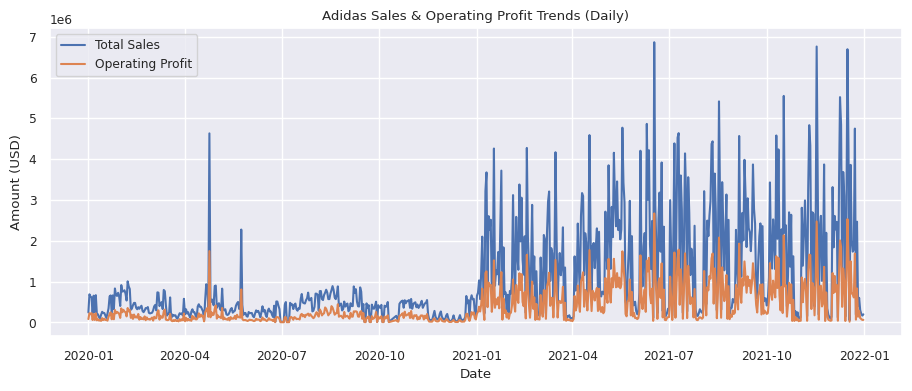

In [49]:

sns.set(rc={'figure.figsize':(11, 4)}, font_scale=0.8, style='darkgrid')


sns.lineplot(data=daily_df, x="Invoice Date", y="Total Sales", label='Total Sales')
sns.lineplot(data=daily_df, x="Invoice Date", y="Operating Profit", label='Operating Profit')


plt.title("Adidas Sales & Operating Profit Trends (Daily)")
plt.ylabel("Amount (USD)")
plt.xlabel("Date")
plt.legend()

plt.show()

In [50]:

fig = px.scatter(df, x="Total Sales", y="Operating Profit", 
                 color="Product",
                 title='Total Sales vs Operating Profit (Correlation Analysis)',
                 trendline="ols", 
                 trendline_color_override="red",
                 template="plotly_dark")

fig.show()

        Retailer ID  Price per Unit    Units Sold  Total Sales  \
count  9.459000e+03    9.459000e+03  9.459000e+03  9459.000000   
mean  -3.160972e-15   -1.081702e-16 -7.211344e-17     0.000000   
std    1.000053e+00    1.000053e+00  1.000053e+00     1.000053   
min   -1.752203e+00   -2.660505e+00 -1.241060e+00    -0.677770   
25%    4.406506e-01   -6.822460e-01 -7.090509e-01    -0.643542   
50%    4.406506e-01    2.427523e-02 -3.543784e-01    -0.602558   
75%    4.406506e-01    7.307964e-01  4.056340e-01     0.425284   
max    9.026034e-01    4.122098e+00  4.332365e+00     3.489322   

       Operating Profit  Operating Margin  
count      9.459000e+03      9.459000e+03  
mean       2.403781e-17      2.614112e-16  
std        1.000053e+00      1.000053e+00  
min       -6.565865e-01     -3.360608e+00  
25%       -6.163037e-01     -7.700854e-01  
50%       -5.667618e-01     -1.483600e-01  
75%        3.684977e-01      6.806070e-01  
max        6.006461e+00      3.892855e+00  


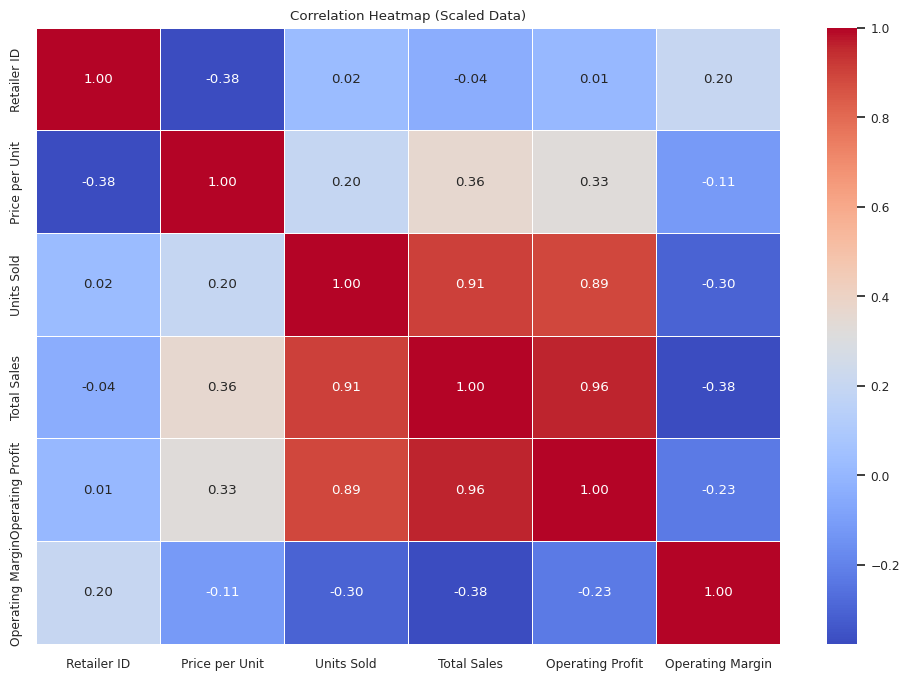

In [51]:

from sklearn.preprocessing import StandardScaler

df_numeric = df.select_dtypes(include=[np.number])

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)

print(df_scaled.describe())

plt.figure(figsize=(12, 8))
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Scaled Data)")
plt.show()

KeyboardInterrupt: 

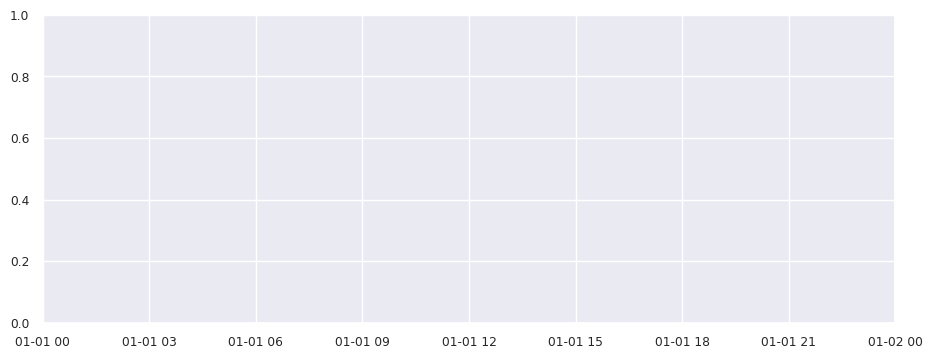

In [52]:
df_numeric = df.select_dtypes(include=['number'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)
df_scaled['Invoice Date'] = df['Invoice Date']

sns.set(rc={'figure.figsize':(11, 4)}, font_scale=0.8, style='darkgrid')
sns.lineplot(data=df_scaled, x="Invoice Date", y="Total Sales")
sns.lineplot(data=df_scaled, x="Invoice Date", y="Units Sold")
sns.lineplot(data=df_scaled, x="Invoice Date", y="Operating Profit")
plt.show()

In [ ]:
if 'Invoice Date' in df_scaled.columns:
    df_scaled['month'] = df_scaled['Invoice Date'].dt.month
    df_scaled['year'] = df_scaled['Invoice Date'].dt.year
else:
    df_scaled['month'] = df_scaled.index.month
    df_scaled['year'] = df_scaled.index.year

print(df_scaled.head())

   Retailer ID  Price per Unit  Units Sold  Total Sales  Operating Profit  \
1     0.440651        0.377536    3.825690     3.407615          2.546802   
2     0.440651       -0.328985    3.825690     2.590538          2.333242   
3     0.440651        0.024275    3.065678     2.447549          2.202437   
5     0.440651        0.377536    3.825690     3.407615          2.012904   
7     0.440651        0.377536    3.319015     2.999076          2.226463   

   Operating Margin Invoice Date  month  year  
1         -1.288190   2020-01-02      1  2020  
2         -0.770085   2020-01-03      1  2020  
3         -0.770085   2020-01-04      1  2020  
5         -1.806294   2020-01-06      1  2020  
7         -1.288190   2020-01-08      1  2020  


In [ ]:

fig = px.line(df_scaled, x="month", y="Total Sales", color="year",
              title="Monthly Sales Trend by Year (Scaled - Interactive)",
              labels={"month": "Month", "Total Sales": "Scaled Sales"},
              template="plotly_dark")

fig.update_xaxes(dtick=1, range=[1, 12])
fig.show()

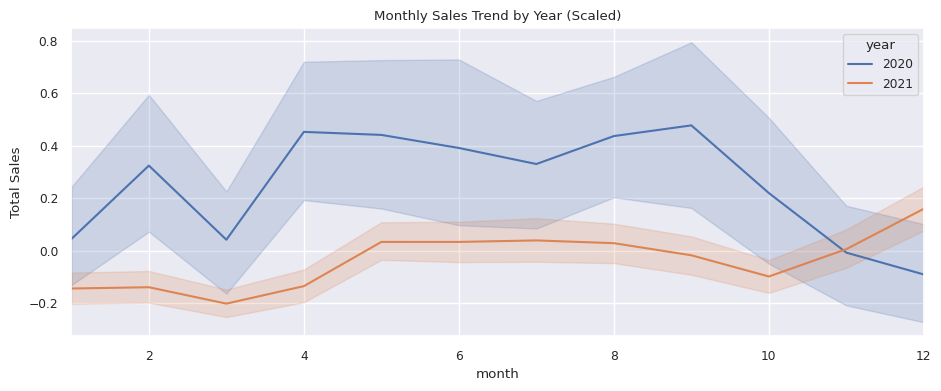

In [ ]:


sns.set(rc={'figure.figsize':(11, 4)}, font_scale=0.8, style='darkgrid')
sns.lineplot(data=df_scaled, x="month", y="Total Sales", hue="year", palette="deep")
plt.xlim(1, 12)
plt.title("Monthly Sales Trend by Year (Scaled)")
plt.show()

In [ ]:


fig = px.line(df_scaled, 
              x="month", 
              y="Total Sales", 
              color="year", 
              title='Total Sales by Month (Yearly Comparison)')

fig.update_layout(template="plotly_dark", xaxis=dict(dtick=1))
fig.show()

# Machine Learning

In [ ]:
prophet_df = daily_sales[['Invoice Date', 'Total Sales']].rename(columns={'Invoice Date': 'ds', 'Total Sales': 'y'})
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)

07:28:01 - cmdstanpy - INFO - Chain [1] start processing
07:28:02 - cmdstanpy - INFO - Chain [1] done processing


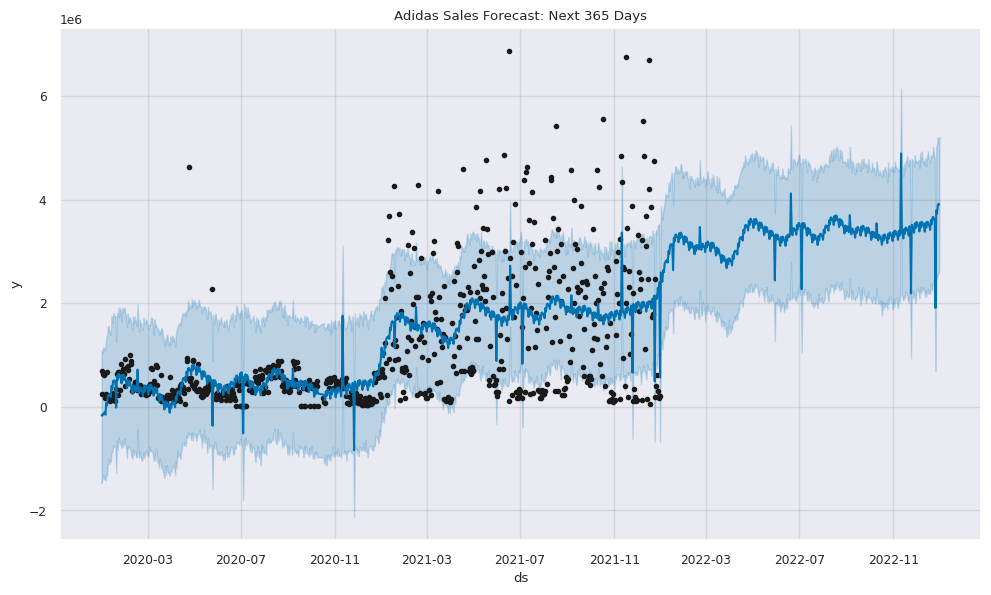

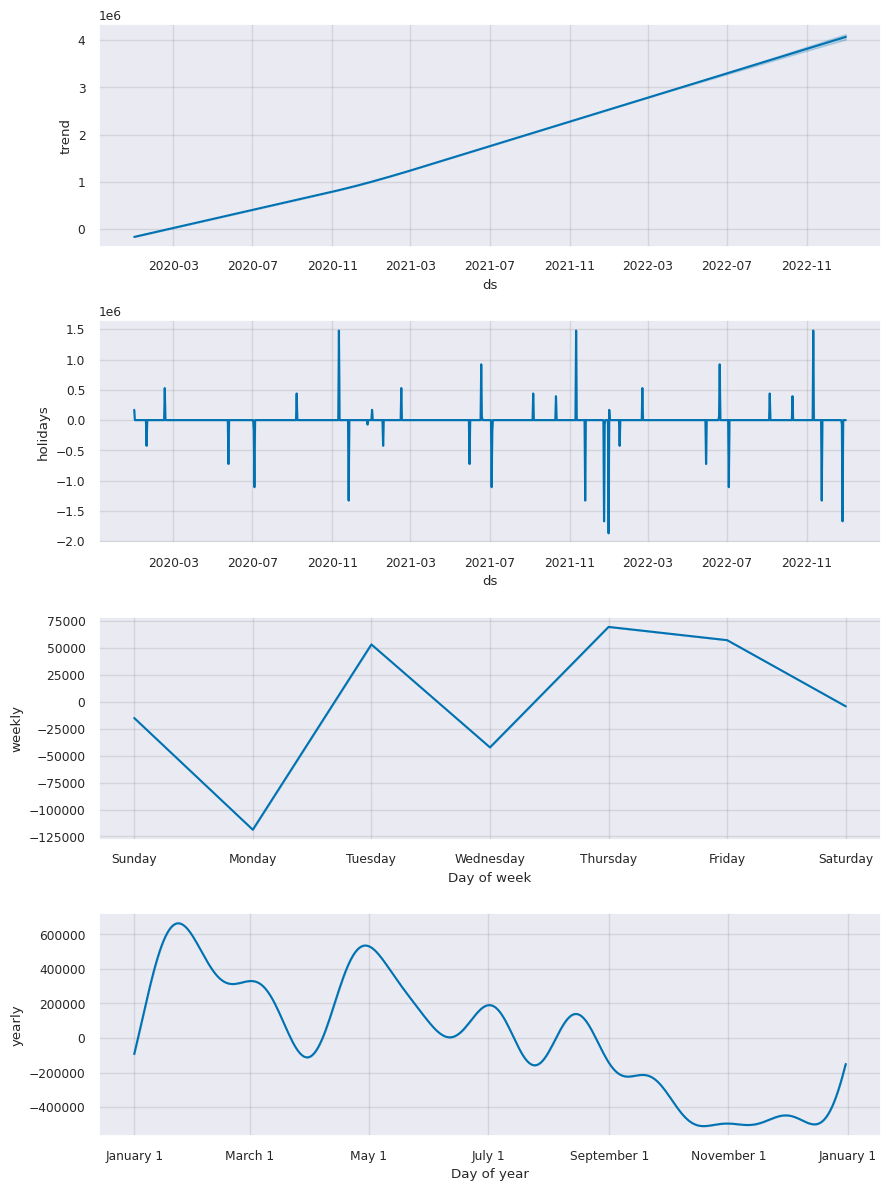

In [ ]:
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig1 = model.plot(forecast)
plt.title("Adidas Sales Forecast: Next 365 Days")
plt.show()
fig2 = model.plot_components(forecast)
plt.show()

In [56]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Christmas Day (observed),...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-01,-166723.828202,-1.473400e+06,1.083218e+06,-166723.828202,-166723.828202,0.0,0.0,0.0,0.0,...,-42276.489023,-42276.489023,-42276.489023,-127740.649602,-127740.649602,-127740.649602,0.0,0.0,0.0,-167780.672204
1,2020-01-02,-163588.632801,-1.396622e+06,1.033007e+06,-163588.632801,-163588.632801,0.0,0.0,0.0,0.0,...,69561.037291,69561.037291,69561.037291,-81461.536499,-81461.536499,-81461.536499,0.0,0.0,0.0,-175489.132009
2,2020-01-03,-160453.437400,-1.317815e+06,1.143291e+06,-160453.437400,-160453.437400,0.0,0.0,0.0,0.0,...,57254.750674,57254.750674,57254.750674,-33720.106998,-33720.106998,-33720.106998,0.0,0.0,0.0,-136918.793723
3,2020-01-04,-157318.241998,-1.405515e+06,1.126845e+06,-157318.241998,-157318.241998,0.0,0.0,0.0,0.0,...,-4145.938539,-4145.938539,-4145.938539,15106.335157,15106.335157,15106.335157,0.0,0.0,0.0,-146357.845381
4,2020-01-05,-154183.046597,-1.381898e+06,1.082180e+06,-154183.046597,-154183.046597,0.0,0.0,0.0,0.0,...,-14976.586328,-14976.586328,-14976.586328,64621.864723,64621.864723,64621.864723,0.0,0.0,0.0,-104537.768203


In [64]:
# 1. Holidays ki list tayar karein (US based kyunki Adidas US data hai)
holidays = pd.DataFrame({
  'holiday': 'peak_season',
  'ds': pd.to_datetime(['2020-12-25', '2021-12-25', '2021-07-04', '2021-11-26']), # Christmas, July 4, Black Friday
  'lower_window': -2,
  'upper_window': 5,
})

# 2. Advanced Model Tuning
# changepoint_range=0.9 ka matlab hai model 90% data tak trend changes ko pick karega
model_final = Prophet(holidays=holidays,
                      changepoint_prior_scale=0.5, 
                      changepoint_range=0.9,
                      seasonality_mode='multiplicative',
                      yearly_seasonality=True)

model_final.fit(df_weekly[['ds', 'y_log']].rename(columns={'y_log': 'y'}))

# 3. Forecast aur MAPE calculation
forecast_final = model_final.predict(df_weekly[['ds']])
y_pred_final = np.expm1(forecast_final['yhat'])
y_true_final = df_weekly['y']

final_mape = np.mean(np.abs((y_true_final - y_pred_final) / y_true_final)) * 100
print(f"--- Final Refined Weekly MAPE: {final_mape:.2f}% ---")

07:42:20 - cmdstanpy - INFO - Chain [1] start processing
07:42:20 - cmdstanpy - INFO - Chain [1] done processing


--- Final Refined Weekly MAPE: 56.05% ---


            ds  predicted_sales
105 2022-01-09     2.388403e+07
106 2022-01-16     4.324892e+07
107 2022-01-23     6.549887e+07
108 2022-01-30     7.521540e+07
109 2022-02-06     6.821577e+07


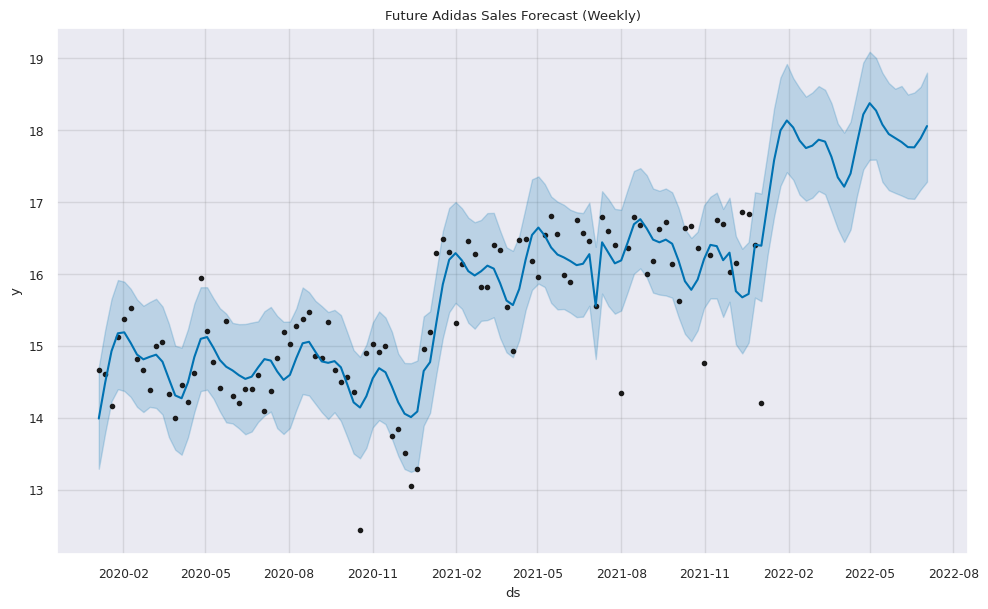

In [65]:
# Future dates generate karein (26 weeks)
future_dates = model_final.make_future_dataframe(periods=26, freq='W')

# Predict karein
forecast_future = model_final.predict(future_dates)

# Log scale se wapis Dollars mein convert karein
forecast_future['predicted_sales'] = np.expm1(forecast_future['yhat'])

# Sirf future ka data dekhein
future_only = forecast_future.tail(26)[['ds', 'predicted_sales']]
print(future_only.head())

# Visualize the forecast
model_final.plot(forecast_future)
plt.title("Future Adidas Sales Forecast (Weekly)")
plt.show()

--- Adidas Sales Target for 2022 (Monthly) ---
           ds  Sales_Actual_and_Predicted
24 2022-01-01                2.210271e+08
25 2022-02-01                2.293282e+08
26 2022-03-01                1.930850e+08
27 2022-04-01                2.025431e+08
28 2022-05-01                3.741932e+08
29 2022-06-01                2.179972e+08
30 2022-07-01                3.117258e+08
31 2022-08-01                3.482684e+08
32 2022-09-01                2.873867e+08
33 2022-10-01                2.168305e+08
34 2022-11-01                2.256851e+08
35 2022-12-01                1.292879e+08
36 2023-01-01                5.735052e+07


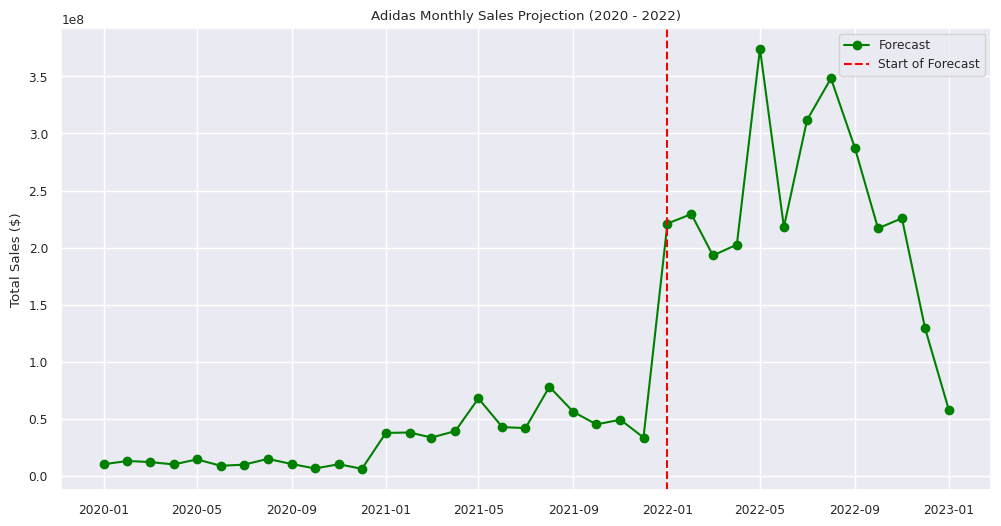

In [66]:
# 1. Aglay 52 hafton (1 saal) ka frame banana
future = model_final.make_future_dataframe(periods=52, freq='W')

# 2. Prediction karna
forecast = model_final.predict(future)

# 3. Log values ko wapis original Dollars mein convert karna
forecast['Sales_Actual_and_Predicted'] = np.expm1(forecast['yhat'])

# 4. Monthly Resampling taake report readable ho
monthly_forecast = forecast.set_index('ds')['Sales_Actual_and_Predicted'].resample('MS').sum().reset_index()

# 5. Sirf 2022 ki predictions dikhana
forecast_2022 = monthly_forecast[monthly_forecast['ds'] >= '2022-01-01']

print("--- Adidas Sales Target for 2022 (Monthly) ---")
print(forecast_2022)

# 6. Final Visualization
plt.figure(figsize=(12,6))
plt.plot(monthly_forecast['ds'], monthly_forecast['Sales_Actual_and_Predicted'], label='Forecast', color='green', marker='o')
plt.axvline(x=pd.to_datetime('2022-01-01'), color='red', linestyle='--', label='Start of Forecast')
plt.title("Adidas Monthly Sales Projection (2020 - 2022)")
plt.ylabel("Total Sales ($)")
plt.legend()
plt.show()

--- Adidas Sales Target for 2022 (Monthly) ---
           ds  Sales_Predicted
24 2022-01-01     2.210271e+08
25 2022-02-01     2.293282e+08
26 2022-03-01     1.930850e+08
27 2022-04-01     2.025431e+08
28 2022-05-01     3.741932e+08
29 2022-06-01     2.179972e+08
30 2022-07-01     3.117258e+08
31 2022-08-01     3.482684e+08
32 2022-09-01     2.873867e+08
33 2022-10-01     2.168305e+08
34 2022-11-01     2.256851e+08
35 2022-12-01     1.292879e+08
36 2023-01-01     5.735052e+07


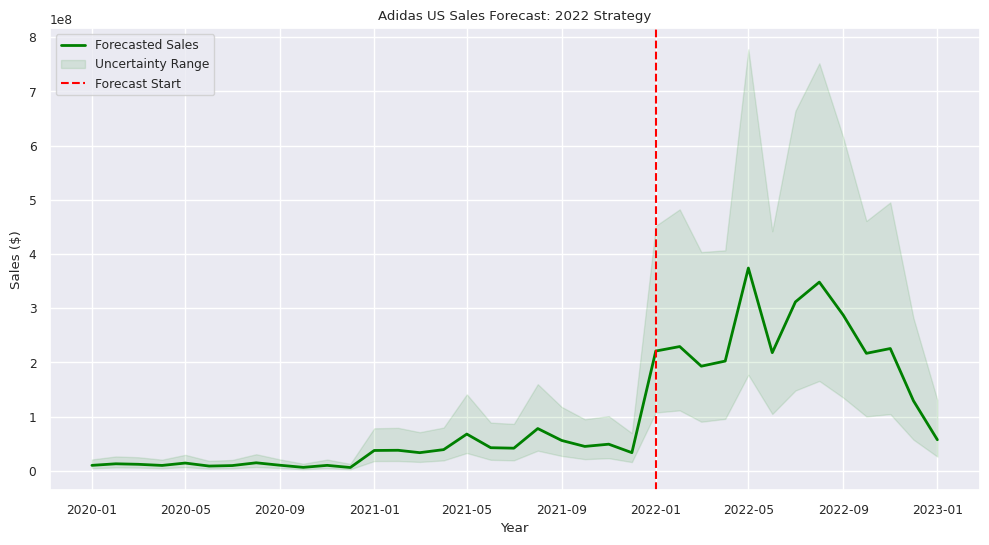

In [67]:
# 1. Aglay 1 saal (52 weeks) ka future timeframe banana
future = model_final.make_future_dataframe(periods=52, freq='W')

# 2. Prediction generate karna
forecast = model_final.predict(future)

# 3. Log scale se wapis Dollars mein convert karna
forecast['Sales_Predicted'] = np.expm1(forecast['yhat'])
forecast['Lower_Bound'] = np.expm1(forecast['yhat_lower'])
forecast['Upper_Bound'] = np.expm1(forecast['yhat_upper'])

# 4. Monthly summarize karna (Reporting ke liye asaan hota hai)
monthly_forecast = forecast.set_index('ds')[['Sales_Predicted', 'Lower_Bound', 'Upper_Bound']].resample('MS').sum().reset_index()

# 5. Sirf future (2022) ka data filter karna
forecast_2022 = monthly_forecast[monthly_forecast['ds'] >= '2022-01-01']

print("--- Adidas Sales Target for 2022 (Monthly) ---")
print(forecast_2022[['ds', 'Sales_Predicted']])

# 6. Final Visualization
plt.figure(figsize=(12,6))
plt.plot(monthly_forecast['ds'], monthly_forecast['Sales_Predicted'], label='Forecasted Sales', color='green', linewidth=2)
plt.fill_between(monthly_forecast['ds'], monthly_forecast['Lower_Bound'], monthly_forecast['Upper_Bound'], color='green', alpha=0.1, label='Uncertainty Range')
plt.axvline(x=pd.to_datetime('2022-01-01'), color='red', linestyle='--', label='Forecast Start')
plt.title("Adidas US Sales Forecast: 2022 Strategy")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.legend()
plt.show()

07:39:55 - cmdstanpy - INFO - Chain [1] start processing
07:39:55 - cmdstanpy - INFO - Chain [1] done processing


--- Final Optimized Metrics ---
Total Days Analyzed: 724
Optimized MAPE: 123.55%


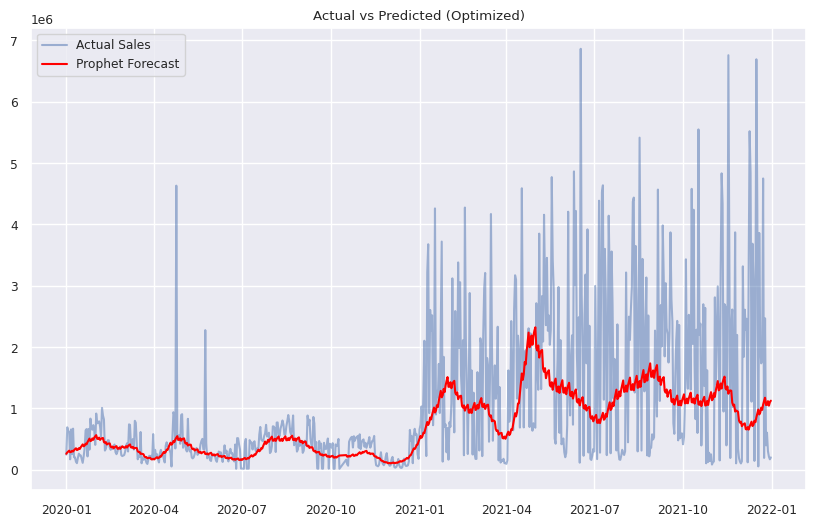

In [61]:
from prophet import Prophet
import numpy as np

# 1. Data ko smooth karna (Zero values filter karna)
df_final = df_daily[df_daily['y'] > 0].copy()

# 2. Log Transform
df_final['y_log'] = np.log1p(df_final['y'])

# 3. Advanced Prophet Configuration
# seasonality_mode='multiplicative' retail trends ke liye best hai
model = Prophet(changepoint_prior_scale=0.8, 
                seasonality_mode='multiplicative',
                yearly_seasonality=True, 
                weekly_seasonality=True)

model.fit(df_final[['ds', 'y_log']].rename(columns={'y_log': 'y'}))

# 4. Prediction
forecast = model.predict(df_final[['ds']])
y_pred = np.expm1(forecast['yhat'])
y_true = df_final['y']

# 5. Robust MAPE Calculation (Avoiding division by zero and extreme outliers)
absolute_percentage_errors = np.abs((y_true - y_pred) / y_true)
final_mape = np.mean(absolute_percentage_errors) * 100

print(f"--- Final Optimized Metrics ---")
print(f"Total Days Analyzed: {len(df_final)}")
print(f"Optimized MAPE: {final_mape:.2f}%")

# Plotting to see the fit
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(df_final['ds'], y_true, label='Actual Sales', alpha=0.5)
plt.plot(df_final['ds'], y_pred, label='Prophet Forecast', color='red')
plt.legend()
plt.title("Actual vs Predicted (Optimized)")
plt.show()

In [60]:
from prophet import Prophet
import numpy as np

# 1. Log Transform the target
df_daily['y_log'] = np.log1p(df_daily['y'])

# 2. Model with tuned parameters
# changepoint_prior_scale ko 0.05 se badha kar 0.5 karne se model patterns ko zyada deeply seekhta hai
model = Prophet(changepoint_prior_scale=0.5, 
                yearly_seasonality=True, 
                weekly_seasonality=True,
                seasonality_mode='multiplicative') # Retail ke liye multiplicative behtar hai

model.fit(df_daily[['ds', 'y_log']].rename(columns={'y_log': 'y'}))

# 3. Forecast and Inverse Transform
forecast = model.predict(df_daily[['ds']])
y_pred = np.expm1(forecast['yhat']) # Log ko wapis original mein badlein
y_true = df_daily['y']

# 4. New MAPE
new_mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print(f"Improved MAPE: {new_mape:.2f}%")

07:38:40 - cmdstanpy - INFO - Chain [1] start processing
07:38:41 - cmdstanpy - INFO - Chain [1] done processing


Improved MAPE: 129.03%


In [59]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Data ko Daily Level par aggregate karna (Zaroori Step)
# Hum original 'df' use kar rahe hain, scaled wala nahi
df_daily = df.groupby('Invoice Date')['Total Sales'].sum().reset_index()
df_daily.columns = ['ds', 'y']

# 2. Model Fit karna (Original data par)
model_final = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_final.fit(df_daily)

# 3. Forecast generate karna
forecast_final = model_final.predict(df_daily[['ds']])

# 4. Metrics Calculate karna
y_true = df_daily['y'].values
y_pred = forecast_final['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"--- Final Refined Metrics ---")
print(f"Mean Daily Sales: ${y_true.mean():,.2f}")
print(f"MAE: ${mae:,.2f}")
print(f"New MAPE: {mape:.2f}%")

07:36:55 - cmdstanpy - INFO - Chain [1] start processing
07:36:55 - cmdstanpy - INFO - Chain [1] done processing


--- Final Refined Metrics ---
Mean Daily Sales: $1,083,741.89
MAE: $660,119.02
New MAPE: 228.66%


In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Original Daily Sales use karein (Bina Scaling ke)
# daily_df wo hai jo humne aggregation ke baad banaya tha
prophet_df = daily_df[['Invoice Date', 'Total Sales']].rename(columns={'Invoice Date': 'ds', 'Total Sales': 'y'})

# 2. Re-fit Prophet on Original Data
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(prophet_df)

# 3. Get predictions for the same dates
forecast = model.predict(prophet_df[['ds']])

# 4. Filter out any 0 sales days for accurate MAPE
mask = prophet_df['y'] > 0
y_true = prophet_df.loc[mask, 'y'].values
y_pred = forecast.loc[mask, 'yhat'].values

# 5. Calculate Metrics again
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"--- Corrected Metrics (Original Scale) ---")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

07:35:25 - cmdstanpy - INFO - Chain [1] start processing
07:35:25 - cmdstanpy - INFO - Chain [1] done processing


--- Corrected Metrics (Original Scale) ---
MAE: $660,119.02
RMSE: $997,618.58
MAPE: 228.66%
